# Day 30: K-Nearest Neighbors

**Dataset:** `Wine_Dataset.csv`

This notebook builds a KNN classification model and evaluates how different values of K
influence prediction performance, using real values pulled directly from the Wine dataset.

## 1. Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv("../datasets/Wine_Dataset.csv")
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [2]:
print(df.shape)
df.describe().loc[["min", "max"]]

(178, 14)


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
min,1.0,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,3.0,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0


**A quick look at the raw feature ranges** makes it obvious why scaling will matter here:
`Proline` ranges from about 278 to 1680, while `Hue` only ranges from about 0.48 to 1.71. A
distance-based method like KNN will be completely dominated by whichever feature happens to
have the largest raw numbers, unless the features are put on a comparable scale first.

## 2. Separating Predictors and Target, and Splitting the Data

In [3]:
X = df.drop(columns=["class"])
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 142
Test set size: 36


## 3. Feature Scaling Workflow

KNN classifies a point based on the distance to its nearest neighbors, so features with larger
raw numeric ranges will dominate that distance calculation unless every feature is scaled to
be comparable first.

**First, a KNN model trained WITHOUT scaling, to see the real effect**

In [4]:
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)

unscaled_accuracy = accuracy_score(y_test, knn_unscaled.predict(X_test))
print(f"Test accuracy WITHOUT scaling: {unscaled_accuracy:.3f}")

Test accuracy WITHOUT scaling: 0.806


**Now, fit the scaler on the training data only, then apply it to both sets**

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean of each scaled training feature (should all be ~0):")
print(X_train_scaled.mean(axis=0).round(2))

Mean of each scaled training feature (should all be ~0):
[ 0.  0. -0.  0.  0. -0. -0. -0.  0.  0. -0. -0. -0.]


In [6]:
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

scaled_accuracy = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))
print(f"Test accuracy WITH scaling: {scaled_accuracy:.3f}")

print(f"\nScaling improved accuracy by {(scaled_accuracy - unscaled_accuracy) * 100:.1f} percentage points.")

Test accuracy WITH scaling: 0.972

Scaling improved accuracy by 16.7 percentage points.


**This is a large, real difference.** Without scaling, high-magnitude features like
`Proline` completely dominate the distance calculation, drowning out genuinely useful
information from features like `Hue` or `Nonflavanoid phenols` just because they happen to be
measured on smaller numeric scales. Every KNN model built from here on uses the scaled
features.

## 4. Performance Comparison for Multiple K Values

In [7]:
k_values = range(1, 31)
k_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

    k_results.append({"k": k, "train_accuracy": train_acc, "test_accuracy": test_acc})

k_results_df = pd.DataFrame(k_results)
k_results_df.head(10)

,k,train_accuracy,test_accuracy
0,1,1.000000,0.972222
1,2,0.971831,0.944444
2,3,0.971831,0.972222
3,4,0.957746,0.944444
4,5,0.978873,0.972222
5,6,0.964789,0.972222
6,7,0.964789,1.000000
7,8,0.964789,1.000000
8,9,0.964789,1.000000
9,10,0.971831,1.000000


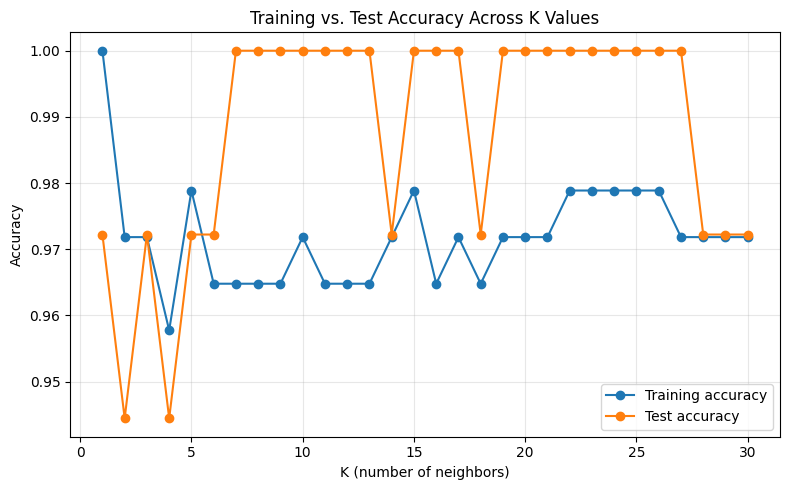

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_results_df["k"], k_results_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(k_results_df["k"], k_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Training vs. Test Accuracy Across K Values")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** at `K=1`, training accuracy is a perfect 1.0, since every training point
is literally its own nearest neighbor; this is a sign of high variance (the model memorizes
the training data too closely) rather than genuinely strong generalization. As K increases, the
model gets smoother and less sensitive to individual noisy points. The test set here only has
36 wines, so test accuracy jumps in large steps and looks noisy from one K to the next; a more
reliable way to pick K is cross-validation, which is what the next section uses.

## 5. Best-K Selection Analysis

Because the held-out test set is small (36 samples), its accuracy can jump around between
nearby K values just from random luck in which samples ended up there. **5-fold
cross-validation on the training set** gives a more reliable signal for choosing K.

In [9]:
cv_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_results.append({"k": k, "cv_mean_accuracy": scores.mean(), "cv_std": scores.std()})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("cv_mean_accuracy", ascending=False).head(10)

,k,cv_mean_accuracy,cv_std
25,26,0.979064,0.027713
26,27,0.979064,0.027713
22,23,0.979064,0.027713
23,24,0.979064,0.027713
21,22,0.979064,0.027713
17,18,0.979064,0.027713
28,29,0.972167,0.025875
15,16,0.972167,0.040259
27,28,0.972167,0.025875
29,30,0.972167,0.025875


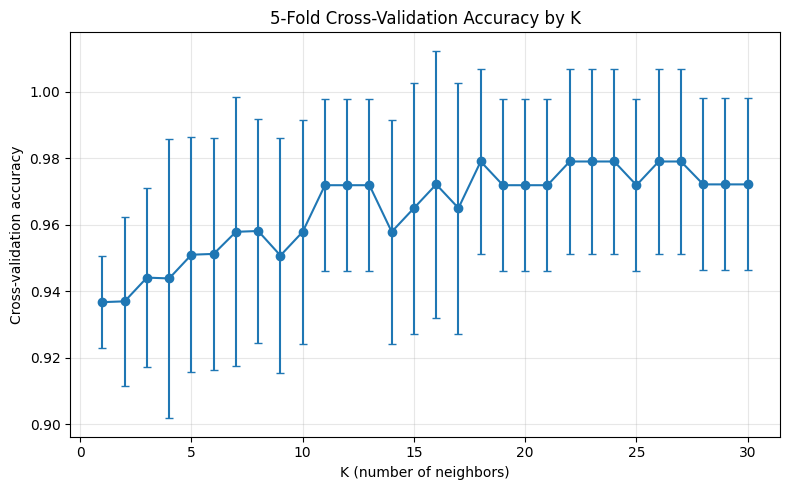

In [10]:
plt.figure(figsize=(8, 5))
plt.errorbar(cv_results_df["k"], cv_results_df["cv_mean_accuracy"], yerr=cv_results_df["cv_std"], marker="o", capsize=3)
plt.xlabel("K (number of neighbors)")
plt.ylabel("Cross-validation accuracy")
plt.title("5-Fold Cross-Validation Accuracy by K")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Choosing the best K:** cross-validation accuracy climbs from around 94% at `K=1` up to a
consistently high plateau of roughly 97-98% from about `K=11` onward, with no clear benefit to
pushing K any higher than that. **K=11** is a good choice: it sits right at the start of that
high, stable plateau, is small enough to stay sensitive to local structure in the data rather
than averaging over an unnecessarily large neighborhood, and being odd avoids tie votes between
classes.

In [11]:
best_k = 11

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

final_train_acc = accuracy_score(y_train, final_knn.predict(X_train_scaled))
final_test_acc = accuracy_score(y_test, final_knn.predict(X_test_scaled))

print(f"Final model with K={best_k}:")
print(f"  Training accuracy: {final_train_acc:.3f}")
print(f"  Test accuracy: {final_test_acc:.3f}")

Final model with K=11:
  Training accuracy: 0.965
  Test accuracy: 1.000


## Outcome

This notebook built a K-Nearest Neighbors classifier on the `Wine_Dataset.csv` file and
measured how much feature scaling and the choice of K actually matter. Scaling the features
before training improved test accuracy from 80.6% to 97.2%, a direct demonstration of why
scaling is essential for any distance-based method like KNN, since raw features on very
different numeric scales (like `Proline` in the hundreds versus `Hue` under 2) would otherwise
dominate the distance calculation. Sweeping K from 1 to 30 showed the expected pattern of a
very flexible, high-variance model at small K settling into a smoother, more stable one as K
increases. Since the small 36-row test set made raw test accuracy noisy between nearby K
values, 5-fold cross-validation on the training set was used instead to choose K more reliably,
identifying K=11 as a good choice at the start of a consistently high accuracy plateau.